В этой лабораторной работе будут задействованы полносвязные слои. Необходимо решить ряд задач с их помощью.  Набор библиотек: tensorflow, numpy, matplotlib, random

In [26]:
# imports

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
import math

In [27]:
# constants

total_points = 1000
first_group_proportion = 0.5
first_group_lower_r, first_group_upper_r = 0, 0.8
second_group_lower_r, second_group_upper_r = 1, 2

Первая задача - классификация генерированных данных. Для начала сформируйте датасет по следующему принципу: первая группа точек (первый класс) распределена по площади круга радиусом 0.8, вторая группа - по площади кольца с R=2 и r=1. Суммарное количество точек N=1000, соотношение классов - 1:1.

По заданным условиям сгенерируйте две координаты для каждой точки как случайные величины, набор этих координат занесите в массив X_train. Каждой точке из этого массива должен соответствовать лейбл класса - его занесите в y_train. Постройте график распределения.

In [28]:
def generate_points(r_lower: float, r_upper: float, num_points: int):
    # generate polar coordinates and map them to the required figure
    r_inside = np.sqrt(np.random.uniform(r_lower, r_upper**2, num_points))
    theta_inside = np.random.uniform(0, 2*np.pi, num_points)
    x_inside = r_inside * np.cos(theta_inside)
    y_inside = r_inside * np.sin(theta_inside)
    return np.array([x_inside, y_inside]).T

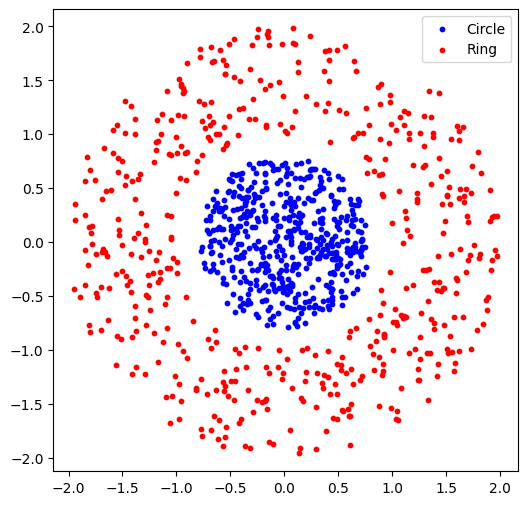

In [29]:
circle = generate_points(
    first_group_lower_r,
    first_group_upper_r,
    int(total_points*first_group_proportion)
    )
ring = generate_points(
    second_group_lower_r,
    second_group_upper_r,
    int(total_points*(1-first_group_proportion))
    )

plt.figure(figsize=(6,6))
plt.scatter(circle[:, 0], circle[:, 1], color='blue', s=10, label='Circle')
plt.scatter(ring[:, 0],ring[:, 1], color='red', s=10, label='Ring')
plt.legend()
plt.axis("equal")
plt.show()

In [30]:
# create (X, y) pairs and cast them to tf array for some memmroy thing
features = tf.convert_to_tensor(np.append(circle, ring, axis=0))
target = tf.convert_to_tensor(np.append(np.ones((len(circle), 1)),
                   np.zeros((len(ring), 1))).reshape(-1, 1))

Классифицируйте эти данные с помощью трех разных моделей, использующих полносвязные слои. Для всех моделей используйте метрику accuracy. Первая модель должна иметь не более двух слоев (включая выходной) и по два нейрона в каждом слое. Во второй модели добавьте к первому слою ещё один нейрон. Последнюю модель составляйте по своему усмотрению с целью максимально быстро добиться 100% точности.

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

test_train_split = 0.2

# avoid overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [36]:
model_1 = Sequential([
        Dense(2),
        tf.keras.layers.LeakyReLU(negative_slope=0.1),  # should not count as a layer?
        Dense(1, activation='sigmoid')
    ])

model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model_1.fit(features, target, epochs=50, batch_size=200, validation_split=test_train_split, callbacks=[early_stopping])
y_pred = (model_1.predict(features) > 0.5).astype(int)
accuracy_score(target, y_pred)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.4760 - loss: 0.7141 - val_accuracy: 0.4950 - val_loss: 0.7589
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5258 - loss: 0.7069 - val_accuracy: 0.4700 - val_loss: 0.7594
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5387 - loss: 0.7070 - val_accuracy: 0.4600 - val_loss: 0.7600
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5632 - loss: 0.7085 - val_accuracy: 0.4400 - val_loss: 0.7605
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5903 - loss: 0.7025 - val_accuracy: 0.4000 - val_loss: 0.7610
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6008 - loss: 0.7043 - val_accuracy: 0.3900 - val_loss: 0.7615
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


0.517

In [37]:
model_2 = Sequential([
        Dense(3),
        tf.keras.layers.LeakyReLU(negative_slope=0.1),
        Dense(1, activation='sigmoid')
    ])

model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model_2.fit(features, target, epochs=50, batch_size=200, validation_split=test_train_split, callbacks=[early_stopping])
y_pred = (model_2.predict(features) > 0.5).astype(int)
accuracy_score(target, y_pred)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - accuracy: 0.4358 - loss: 0.6853 - val_accuracy: 0.7300 - val_loss: 0.6201
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4762 - loss: 0.6800 - val_accuracy: 0.7250 - val_loss: 0.6216
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5003 - loss: 0.6832 - val_accuracy: 0.7050 - val_loss: 0.6234
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5137 - loss: 0.6764 - val_accuracy: 0.6700 - val_loss: 0.6248
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5613 - loss: 0.6742 - val_accuracy: 0.6300 - val_loss: 0.6264
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5430 - loss: 0.6777 - val_accuracy: 0.6100 - val_loss: 0.6277
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


0.517

Грубые подсчеты результатов для 1 и 2 моделей  
1. ~0.68-0.7
2. ~0.69-0.75

Мы работаем с простыми данными, может быть sklearn справится?

In [34]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(kernel='rbf', gamma='scale')
svm.fit(features, target)
print(f"Accuracy: {svm.score(features, target):.4f}")

Accuracy: 1.0000


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Да, справится. Теперь попробую с применением нейронных сетей, если это нужно для задачи. Хотелось бы создать 3 колону (расстояние от 0, 0), но это не честно наверное.

In [38]:
model_3 = Sequential([
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_3 = model_3.fit(features, target, epochs=50, batch_size=200, validation_split=test_train_split, callbacks=[early_stopping])
y_pred = (model_3.predict(features) > 0.5).astype(int)
accuracy_score(target, y_pred)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.3678 - loss: 0.6823 - val_accuracy: 1.0000 - val_loss: 0.6051
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4337 - loss: 0.6734 - val_accuracy: 1.0000 - val_loss: 0.5868
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5030 - loss: 0.6632 - val_accuracy: 1.0000 - val_loss: 0.5676
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5285 - loss: 0.6584 - val_accuracy: 1.0000 - val_loss: 0.5482
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5713 - loss: 0.6514 - val_accuracy: 1.0000 - val_loss: 0.5287
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6292 - loss: 0.6388 - val_accuracy: 1.0000 - val_loss: 0.5078
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6648 - loss: 0.6288 - val_accuracy: 1.0000 - val_loss: 0.4864
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7038 - loss: 0.6180 - val_accuracy: 1.0000 - val_loss: 0.4647
Epoch 9/50


1.0

Теперь добавьте к данным случайные отклонения по координатам таким образом, чтобы точки двух классов смешивались на границе. Для этого, например, можно добавить к генератору координат слагаемое, разыгранное функцией Гаусса, но принимается любой рабочий вариант. Постройте график.

---

Расстояние между границами категорий - 0.2
попробуем добавить шума с таким же стандартным отклонением

In [48]:
def jitter_points(matrix, sigma):
    return matrix + np.random.normal(0, sigma, matrix.shape)

<ipython-input-51-947375a7f1ec>:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


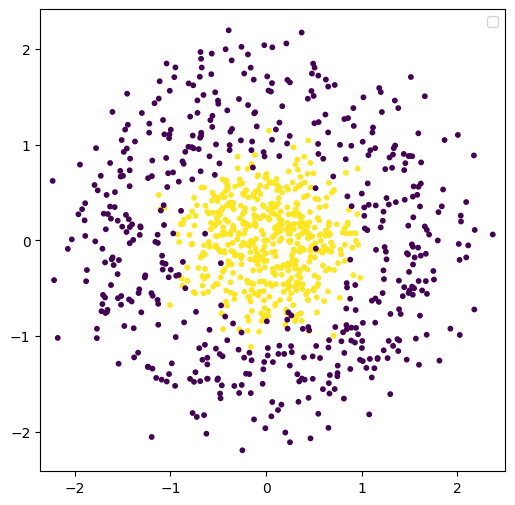

In [51]:
jittered_points = jitter_points(features, 0.2)

plt.figure(figsize=(6,6))
plt.scatter(jittered_points[:, 0], jittered_points[:, 1], c=target, s=10)
plt.legend()
plt.axis("equal")
plt.show()

К этим данным примените третью модель.

In [52]:
history_4 = model_3.fit(jittered_points, target, epochs=50, batch_size=200, validation_split=test_train_split, callbacks=[early_stopping])
y_pred = (model_3.predict(jittered_points) > 0.5).astype(int)
accuracy_score(target, y_pred)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9408 - loss: 0.1455 - val_accuracy: 0.9350 - val_loss: 0.1590
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9520 - loss: 0.1265 - val_accuracy: 0.9100 - val_loss: 0.2322
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9517 - loss: 0.1224 - val_accuracy: 0.9200 - val_loss: 0.2065
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9558 - loss: 0.1195 - val_accuracy: 0.9300 - val_loss: 0.1647
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9605 - loss: 0.1172 - val_accuracy: 0.9400 - val_loss: 0.1459
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9633 - loss: 0.1139 - val_accuracy: 0.9350 - val_loss: 0.1521
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9583 - loss: 0.1205 - val_accuracy: 0.9300 - val_loss: 0.1691
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9583 - loss: 0.1240 - val_accuracy: 0.9300 - val_loss: 0.1827


0.955

Теперь решите задачу классификации для датасета MNIST. Загрузите его любым удобным способом и обучите FC-модель. Точность выше 90% считается удовлетворительной.

In [1]:
%%capture
%pip install opendatasets

In [5]:
import opendatasets as od

# need kaggle.json api key for that
dataset_url = 'https://www.kaggle.com/datasets/hojjatk/mnist-dataset'
od.download(dataset_url)

training_images_filepath = 'mnist-dataset/train-images.idx3-ubyte'
training_labels_filepath = 'mnist-dataset/train-labels.idx1-ubyte'
test_images_filepath = 'mnist-dataset/t10k-images.idx3-ubyte'
test_labels_filepath = 'mnist-dataset/t10k-labels.idx1-ubyte'

Skipping, found downloaded files in "./mnist-dataset" (use force=True to force download)


In [29]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.initializers import HeUniform



from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.data import loadlocal_mnist

In [30]:
X_train, y_train = loadlocal_mnist( training_images_filepath, training_labels_filepath)
X_test, y_test = loadlocal_mnist(test_images_filepath, test_labels_filepath)

In [31]:
X_train = X_train.reshape(60000, 28, 28)
X_test = X_test.reshape(10000, 28, 28)

X_train, X_test = X_train / 255.0, X_test / 255.0

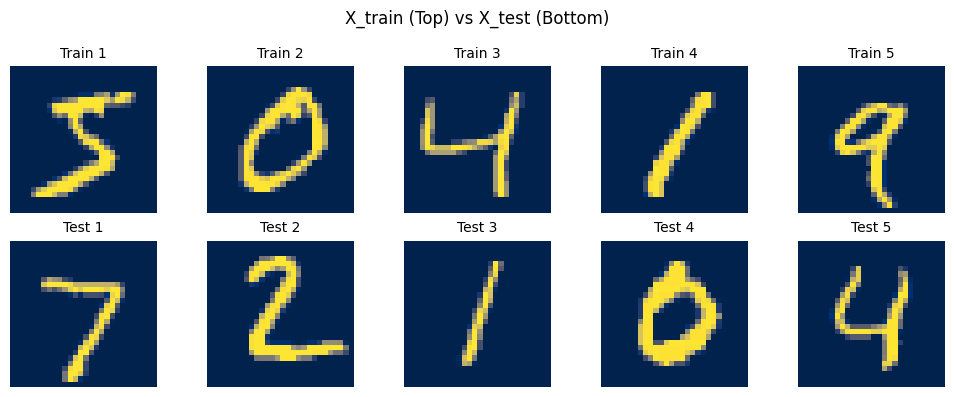

In [32]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))


for i in range(5):
    axes[0, i].imshow(X_train[i].reshape(28, 28), cmap="cividis")
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Train {i+1}", fontsize=10)


for i in range(5):
    axes[1, i].imshow(X_test[i].reshape(28, 28), cmap="cividis")
    axes[1, i].axis('off')
    axes[1, i].set_title(f"Test {i+1}", fontsize=10)

plt.suptitle("X_train (Top) vs X_test (Bottom)", fontsize=12)
plt.tight_layout()
plt.show()


In [33]:
model = Sequential([
    # CNN part
    Conv2D(32, (4,4), activation="relu", kernel_initializer=HeUniform(), input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=HeUniform()),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=HeUniform()),
    Flatten(),

    # Dense neurons
    Dense(64, activation="relu", kernel_initializer=HeUniform()),

    # output
    Dense(10, activation="softmax")
])

In [34]:
model.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy" , metrics=["accuracy"])

In [35]:
fit = model.fit(X_train, y_train , epochs=5 , batch_size=64,validation_data=(X_test,y_test))

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 53s 54ms/step - accuracy: 0.8917 - loss: 0.3442 - val_accuracy: 0.9832 - val_loss: 0.0528
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.9870 - loss: 0.0448 - val_accuracy: 0.9880 - val_loss: 0.0388
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 51ms/step - accuracy: 0.9909 - loss: 0.0299 - val_accuracy: 0.9891 - val_loss: 0.0346
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.9936 - loss: 0.0200 - val_accuracy: 0.9927 - val_loss: 0.0268
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.9945 - loss: 0.0164 - val_accuracy: 0.9917 - val_loss: 0.0258


In [36]:
test_loss, test_acc = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9899 - loss: 0.0313
